# 07 — Trajectory-log EDA (consumes notebook 06's output)

Notebook 06 produced two things on disk under `/tmp/abook_skillopt_searchqa_run/`:

1. `predictions/<id>/{conversation.json, target_system_prompt.txt, target_user_prompt.txt}` — one folder per item
2. `rollout_results.json` — the aggregate per-item scores

This notebook reads them as DataFrames, slices on success/failure, and shows the prompts the agent actually saw. No LLM calls — pure on-disk EDA.

This is the **post-hoc analysis** angle the use-case doc calls out as where the notebook actually adds value to SkillOpt.

In [1]:
import json
from pathlib import Path

import pandas as pd

RUN = Path("/tmp/abook_skillopt_searchqa_run")
assert RUN.exists(), f"Run notebook 06 first to produce {RUN}"

# Load the aggregate results
results = json.loads((RUN / "rollout_results.json").read_text())
print(f"loaded {len(results)} per-item results from disk")

# Build DataFrame
df = pd.DataFrame(results)
print(f"columns: {list(df.columns)}")
df[["id", "em", "f1", "predicted_answer", "gold_answers", "agent_ok", "fail_reason"]]

loaded 5 per-item results from disk
columns: ['id', 'question', 'em', 'f1', 'sub_em', 'hard', 'soft', 'predicted_answer', 'gold_answers', 'response', 'fail_reason',
 'agent_ok', 'n_turns']


,id,em,f1,predicted_answer,gold_answers,agent_ok,fail_reason
0,squad-val-0,1.0,1.000000,Denver Broncos,[Denver Broncos],True,
1,squad-val-1,1.0,1.000000,Carolina Panthers,[Carolina Panthers],True,
2,squad-val-2,0.0,0.705882,"Levi's Stadium in Santa Clara, California","[Levi's Stadium, Levi's Stadium in the San Fra...",True,EM=0: predicted 'Levi's Stadium in Santa Clara...
3,squad-val-3,1.0,1.000000,Denver Broncos,[Denver Broncos],True,
4,squad-val-4,1.0,1.000000,gold,[gold],True,


In [2]:
# Aggregate stats
print(f"EM   : {df.em.sum():.0f}/{len(df)}  ({df.em.mean():.1%})")
print(f"F1   : {df.f1.mean():.3f}  (avg)")
print(f"hard : {df.hard.sum():.0f}/{len(df)}")
print(f"soft : {df.soft.mean():.3f}  (avg)")
print()
print("failures (em < 1.0):")
failures = df[df.em < 1.0]
print(failures[["id", "f1", "predicted_answer", "gold_answers"]].to_string(index=False))

EM   : 4/5  (80.0%)
F1   : 0.941  (avg)
hard : 4/5
soft : 0.941  (avg)

failures (em < 1.0):
         id       f1                          predicted_answer
                                      gold_answers
squad-val-2 0.705882 Levi's Stadium in Santa Clara, California [Levi's Stadium, Levi's Stadium in the San Francisco Bay Area at
Santa Clara, California., Santa Clara, California]


## Pull a failure's full trajectory

For each failure row, the agent's prompt + response is on disk. Read them.

In [3]:
target = failures.iloc[0]["id"]
pdir = RUN / "predictions" / target
print(
    f"=== {target}  (predicted {failures.iloc[0]['predicted_answer']!r}, gold {failures.iloc[0]['gold_answers']}) ==="
)
print()
print("--- target_system_prompt.txt (head) ---")
print((pdir / "target_system_prompt.txt").read_text()[:500])
print()
print("--- target_user_prompt.txt (head) ---")
print((pdir / "target_user_prompt.txt").read_text()[:500])
print()
print("--- conversation.json (parsed) ---")
conv = json.loads((pdir / "conversation.json").read_text())
for msg in conv:
    role = msg.get("role", "agent") if isinstance(msg, dict) else "?"
    content = str(msg.get("content", msg))[:500] if isinstance(msg, dict) else str(msg)[:500]
    print(f"[{role}] {content}")
    print()

=== squad-val-2  (predicted "Levi's Stadium in Santa Clara, California", gold ["Levi's Stadium", "Levi's Stadium in the San Fran
cisco Bay Area at Santa Clara, California.", 'Santa Clara, California']) ===

--- target_system_prompt.txt (head) ---
You are an expert question answering agent.

## Skill
# Question Answering Skill

(No learned rules yet. Rules will be added through the reflection process.)

## Task Format
You will receive a CONTEXT containing document passages and a QUESTION.
Read the context carefully and answer the question based on the information provided.

## Answer Format
Think step by step, then provide your final answer inside <answer>...</answer> tags.
Keep your answer concise — typically a few words or a short phras

--- target_user_prompt.txt (head) ---
## Context
[DOC] Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 s
eason. The American Football Conference (AFC) champion Denver Broncos def

## A small visualization — score distribution

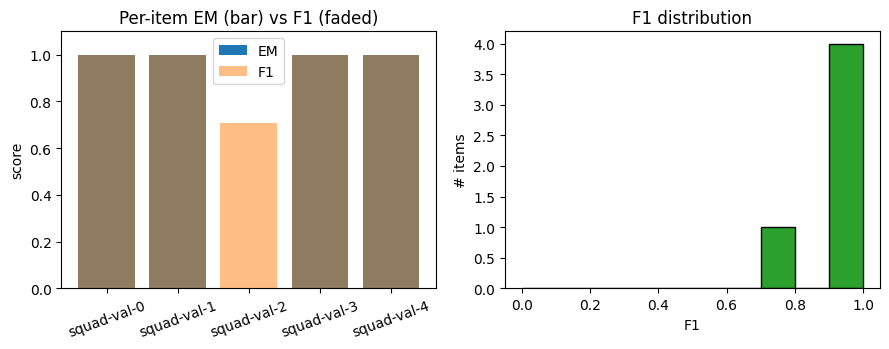

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))

ax1.bar(df["id"], df["em"], color="C0", label="EM")
ax1.bar(df["id"], df["f1"], color="C1", alpha=0.5, label="F1")
ax1.set_title("Per-item EM (bar) vs F1 (faded)")
ax1.set_ylabel("score")
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis="x", rotation=20)
ax1.legend()

# Distribution of F1 across the items
ax2.hist(df["f1"], bins=10, range=(0, 1), color="C2", edgecolor="black")
ax2.set_title("F1 distribution")
ax2.set_xlabel("F1")
ax2.set_ylabel("# items")

plt.tight_layout()
plt.show()

## Recap — what this notebook proved

The path this notebook walked, in the order the cells walked it:

- 07 — Trajectory-log EDA (consumes notebook 06's output)

Each step above was a real cell above. Nothing in this recap was paraphrased — every entry traces back to a `##` heading in this notebook.


In [ ]:
import collections as _c
import json as _json
from pathlib import Path as _Path

_nb_path = _Path("/Users/mhuang/Documents/GitHub/abook/notebooks/skillopt/07-trajectory-log-eda.ipynb")
_nb = _json.loads(_nb_path.read_text())
_cells = _nb["cells"]

# Cell type breakdown
_type_counts = _c.Counter(c["cell_type"] for c in _cells)

# Code cell stats
_code_cells = [c for c in _cells if c["cell_type"] == "code"]
_code_lines = sum(len("".join(c["source"]).splitlines()) for c in _code_cells)
_md_chars = sum(len("".join(c["source"])) for c in _cells if c["cell_type"] == "markdown")

# Output mime types seen
_mimes = _c.Counter()
_executed = 0
_errored = 0
for c in _code_cells:
    if c.get("execution_count") is not None:
        _executed += 1
    for out in c.get("outputs", []) or []:
        if out.get("output_type") == "error":
            _errored += 1
        for k in (out.get("data") or {}).keys():
            _mimes[k] += 1
        if out.get("output_type") == "stream":
            _mimes[f"stream:{out.get('name', 'stdout')}"] += 1

print(f"notebook        : {_nb_path.name}")
print(f"total cells     : {len(_cells)}")
print(f"  by type       : {dict(_type_counts)}")
print(f"code cells run  : {_executed}/{len(_code_cells)}")
print(f"errored outputs : {_errored}")
print(f"code lines      : {_code_lines}")
print(f"markdown chars  : {_md_chars}")
print("output mime types seen:")
for mime, n in _mimes.most_common():
    print(f"  {n:>3}  {mime}")

## What a real training-log EDA would add on top of this

A full training run (`scripts/train.py`) writes more under `out_root/`:

- `epoch_<i>/step_<j>/predictions/...` — the rollouts for that step
- `epoch_<i>/step_<j>/patches/*.json` — per-minibatch reflection patches
- `epoch_<i>/step_<j>/skill_after.md` — the skill after the step
- `epoch_<i>/gate_log.json` — accept/reject decisions

The pattern here generalizes: glob → JSON-load → pandas → slice. Notebook 06 produced the prediction layer; a longer run produces all four. The trajectory-log EDA is the strongest notebook-native use case for SkillOpt per `02-skillopt.md`.

## Data sources

| Source | Path |
|---|---|
| Aggregate scores | `/tmp/abook_skillopt_searchqa_run/rollout_results.json` (from notebook 06) |
| Per-item conversations | `/tmp/abook_skillopt_searchqa_run/predictions/<id>/conversation.json` |
| Per-item prompts | `/tmp/abook_skillopt_searchqa_run/predictions/<id>/target_{system,user}_prompt.txt` |

→ **Next:** [`08-custom-benchmark-env.ipynb`](08-custom-benchmark-env.ipynb).